In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Hyperparameter Optimization

burlington-02
best: 0.0001 0.001


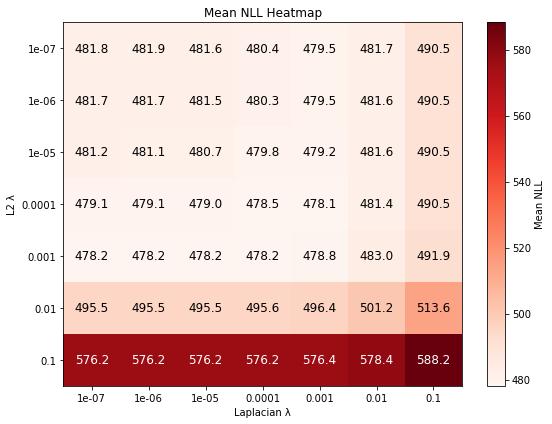

glasgow-04
best: 0.0001 0.001


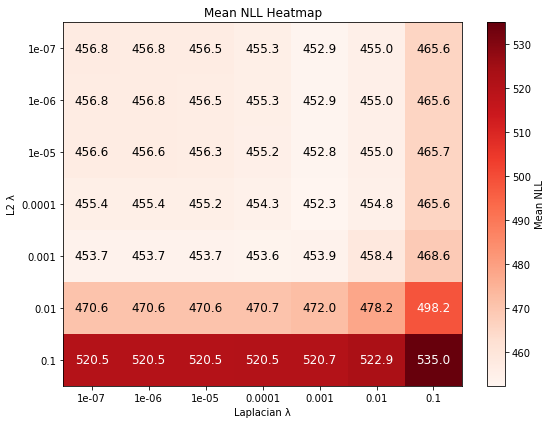

sf-11
best: 1e-07 1e-07


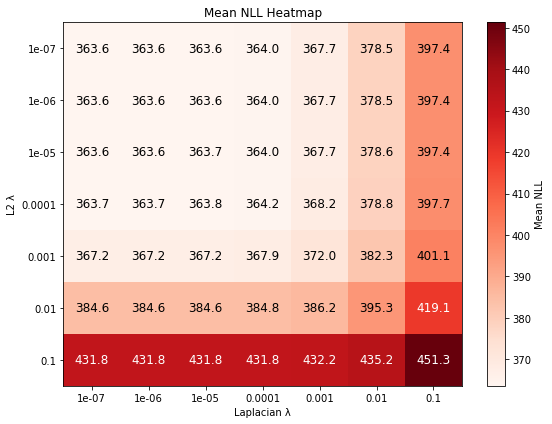

pierce-03
best: 1e-07 1e-07


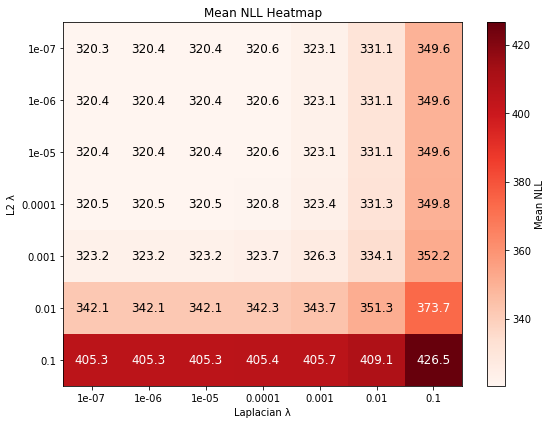

In [2]:
def get_optimal_lam(nlls, annotate=True, cmap="Reds"):
    """
    nlls: dict[l2_lam][laplacian_lam] -> list of NLLs
    """

    l2_lams = sorted(nlls.keys())
    lap_lams = sorted({lap for v in nlls.values() for lap in v})

    # matrix of mean NLLs
    nll_matrix = np.full((len(l2_lams), len(lap_lams)), np.nan)

    lowest_nll = np.inf
    best_l2_lam = None
    best_laplacian_lam = None

    for i, l2_lam in enumerate(l2_lams):
        for j, laplacian_lam in enumerate(lap_lams):
            if laplacian_lam not in nlls[l2_lam]:
                continue

            mean_nll = np.mean(nlls[l2_lam][laplacian_lam])
            nll_matrix[i, j] = mean_nll

            if mean_nll < lowest_nll:
                lowest_nll = mean_nll
                best_l2_lam = l2_lam
                best_laplacian_lam = laplacian_lam

    print("best:", best_l2_lam, best_laplacian_lam)

    # ---- Heatmap ----
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(nll_matrix, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(lap_lams)))
    ax.set_yticks(np.arange(len(l2_lams)))
    ax.set_xticklabels(lap_lams)
    ax.set_yticklabels(l2_lams)

    ax.set_xlabel("Laplacian λ")
    ax.set_ylabel("L2 λ")
    ax.set_title("Mean NLL Heatmap")

    plt.colorbar(im, ax=ax, label="Mean NLL")

    if annotate:
        for i in range(len(l2_lams)):
            for j in range(len(lap_lams)):
                if not np.isnan(nll_matrix[i, j]):
                    ax.text(
                        j, i,
                        f"{nll_matrix[i, j]:.1f}",
                        ha="center", va="center",
                        color="white" if im.norm(nll_matrix[i, j]) > 0.5 else "black",
                        fontsize=12
                    )

    plt.tight_layout()
    plt.show()

    return best_l2_lam, best_laplacian_lam

for election_name in ["burlington-02", "glasgow-04", "sf-11", "pierce-03"]:
    filename = f"../results/hyperparam/push_pull/{election_name}.pickle"
    with open(filename, "rb") as file:
        nlls = pickle.load(file)
    print(election_name)
    get_optimal_lam(nlls)

## KL Divergence

```
Parameters: 
1 trial
poll is sampled with replacement
50 training steps
```

* glasgow: KL_by_election_ED-00008-00000002.soi.pickle
* key-elections: KL_by_election_ED-00023-00000001.toi.pickle
* sf: KL_by_election_ED-00021-00000010.toi.pickle

* Bootstrap results are in KL_by_election_key*

* note: irish election did not finish a single election. others that did not finish: glasgow-03-21, uklabor-01, sf-11-14

* decided that there is no good way to properly define KL divergence for boothstrap unless bootstrap has full support

* results using l2 are in l2_by_election and the corresponding distributions are in inferred_distribution_by_election

## Forecasting

* All win share results are in win_shares_by_election_key* (4 trials)

* ran 50 trials for burlington-02, sl-01, takomapark-01, sf-07. Each has its own pickle file.

In [15]:
with open("../results/push_pull_eval/l2_by_election_filtered_burlington-02.pickle", "rb") as pickleFile:
    KL_results = pickle.load(pickleFile)
    
with open("../results/push_pull_eval/win_shares_by_election_filtered_burlington-02.pickle", "rb") as pickleFile:
    win_shares_results = pickle.load(pickleFile)

In [12]:
directory = Path("../results/push_pull_eval")

KL_results = {}
target_paths = [
    "l2_by_election_200_trials_glasgow-04.pickle",
    "l2_by_election_200_trials_pierce-03.pickle",
    "l2_by_election_200_trials_sf-11.pickle",
    "l2_by_election_200_trials_burlington-02.pickle"
]
for file_path in directory.glob("*.pickle"):
    if file_path.is_file() and file_path.name in target_paths:
        with file_path.open("rb") as f:
            results = pickle.load(f)
            
            for election_name in results:
                KL_results[election_name] = results[election_name]
# validate the results. confirm that the same number of trials completed for all sample sizes.
for election_name in KL_results:
    num_trials = -1
    for model_name in KL_results[election_name]:
        for sample_size in KL_results[election_name][model_name]:
            if num_trials == -1:
                num_trials = len(KL_results[election_name][model_name][sample_size])
            else:
                try:
                    assert len(KL_results[election_name][model_name][sample_size]) == num_trials
                except:
                    print(f"{model_name} {sample_size} {len(KL_results[election_name][model_name][sample_size])} {num_trials}")
    print(f"election: {election_name}\t {num_trials} trials")
    
win_shares_results = {}
target_paths = [
    "win_shares_by_election_200_trials_glasgow-04.pickle",
    "win_shares_by_election_200_trials_pierce-03.pickle",
#     "win_shares_by_election_filtered_sf-11.pickle",
    "win_shares_by_election_200_trials_burlington-02.pickle",

]
for file_path in directory.glob("*.pickle"):
    if file_path.is_file() and file_path.name in target_paths:
        with file_path.open("rb") as f:
            results = pickle.load(f)
            
            for election_name in results:
                win_shares_results[election_name] = results[election_name]
# validate the results. confirm that the total number of wins = num_trials * num_forecasting_simulations
for election_name in win_shares_results:
    num_wins = -1
    for model_name in win_shares_results[election_name]:
        for sample_size in win_shares_results[election_name][model_name]:
            if num_wins == -1:
                num_wins = np.sum([
                    np.sum(win_shares_results[election_name][model_name][sample_size][cand])
                    for cand in win_shares_results[election_name][model_name][sample_size]
                ])
            else:
                try:
                    assert num_wins == np.sum([
                        np.sum(win_shares_results[election_name][model_name][sample_size][cand])
                        for cand in win_shares_results[election_name][model_name][sample_size]
                    ])
                except:
                    print(f"Not enough wins for {model_name} {sample_size}")
    print(f"election: {election_name}\t {num_wins} wins")

Bootstrap 1000 10 200
Bootstrap 2000 10 200
Bootstrap 4000 10 200
PL + Context 1000 10 200
PL + Context 2000 10 200
PL + Context 4000 10 200
PL + Rank + Context + Reg 1000 10 200
PL + Rank + Context + Reg 2000 10 200
PL + Rank + Context + Reg 4000 10 200
election: burlington-02	 200 trials
Bootstrap 1000 10 200
Bootstrap 2000 10 200
Bootstrap 4000 10 200
PL + Context 1000 10 200
PL + Context 2000 10 200
PL + Context 4000 10 200
PL + Rank + Context + Reg 1000 10 200
PL + Rank + Context + Reg 2000 10 200
PL + Rank + Context + Reg 4000 10 200
election: glasgow-04	 200 trials
Bootstrap 1000 10 75
Bootstrap 2000 10 75
Bootstrap 4000 10 75
PL + Context 1000 10 75
PL + Context 2000 10 75
PL + Context 4000 10 75
PL + Rank + Context + Reg 1000 10 75
PL + Rank + Context + Reg 2000 10 75
PL + Rank + Context + Reg 4000 10 75
election: pierce-03	 75 trials
Bootstrap 100 0 75
Bootstrap 250 0 75
Bootstrap 500 0 75
Bootstrap 1000 0 75
Bootstrap 2000 0 75
Bootstrap 4000 0 75
PL + Context 100 0 75
PL + 

In [6]:
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 16
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e"]
def get_color_from_model_name(model_name):
    model_to_color = {
        "Bootstrap": "black",
        "PL": colors[0],
        "PL + Rank": colors[1],
        "PL + Context": colors[2],
        "PL + Rank + Context": colors[3],
        "PL + Rank + Context + Reg": colors[4]
    }
    return model_to_color[model_name]

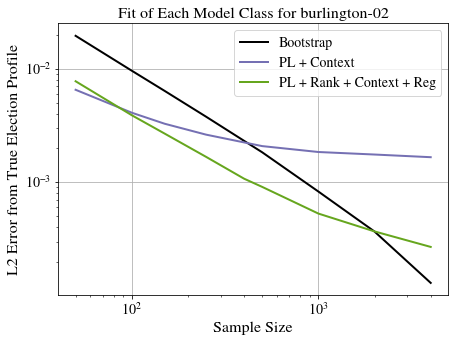

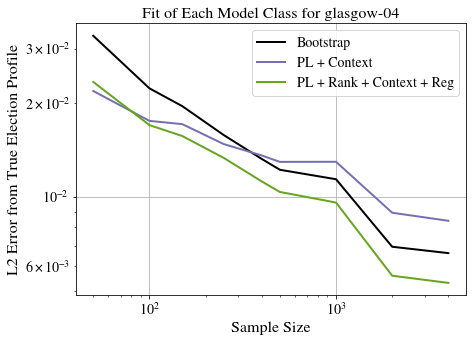

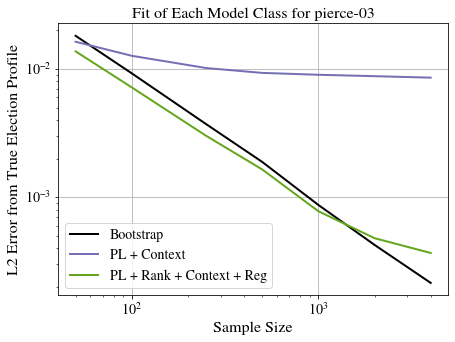

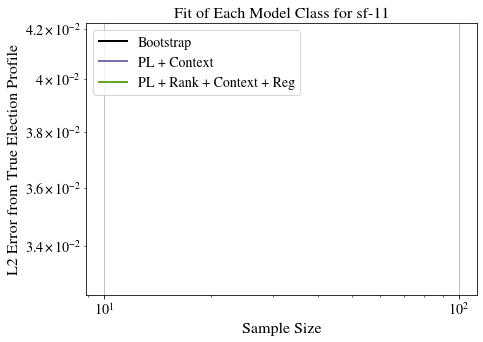

In [9]:
for election_name in KL_results:
    KL_by_sampling_rate = KL_results[election_name]
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_title(f"Fit of Each Model Class for {election_name}")
    ax.set_xlabel("Sample Size")
    ax.set_ylabel("L2 Error from True Election Profile")
    ax.set_yscale("log")
    ax.grid() 
    
#     for model_name in ["Bootstrap", "PL", "PL + Rank", "PL + Context", "PL + Rank + Context",  "PL + Rank + Context + Reg"]:
    for model_name in ["Bootstrap", "PL + Context", "PL + Rank + Context + Reg"]:
        sampling_rates = [rate for rate in KL_by_sampling_rate[model_name]]
        kls = [
            np.mean(KL_by_sampling_rate[model_name][rate]) 
            for rate in sampling_rates
        ]
#         print(kls)
        ax.plot(sampling_rates,
               kls,
               color=get_color_from_model_name(model_name),
               linewidth=2,
               label=model_name)
    ax.set_xscale("log")
    ax.legend()

# Load Election Metadata

In [10]:
# map election_name to winner
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from irv import run_irv
import utils 

election_winners = {}
election_candidates = {}
for data_dir in ["key-elections", "key-1", "key-2"]:
    elections = utils.load_all_preflib_elections(election_dir=f"../data/preflib/{data_dir}")

    for collection, file_name, ballots, ballot_counts, cand_names, _ in elections:
        election_name = f"{collection}-{file_name[-6:-4]}"
        elim_votes = run_irv(len(cand_names),
            ballots.copy(),
            ballot_counts,
            cands=cand_names)
        winner = max(elim_votes, key=elim_votes.get)
        election_winners[election_name] = winner
        election_candidates[election_name] = list(cand_names.keys())
        
with open("../results/push_pull_eval/win_shares_by_election_oracle.pickle", "rb") as pickleFile:
    win_shares_oracle = pickle.load(pickleFile)
    
# unit test for oracle win shares
for election_name in win_shares_oracle:
    cands = election_candidates[election_name]
    for rate in win_shares_oracle[election_name]:
        win_shares = [win_shares_oracle[election_name][rate][cand] for cand in cands]
        assert abs(np.sum(win_shares) - 1.0) < 1e-6
print(win_shares_oracle.keys())
# election_winners

dict_keys(['sf-07', 'burlington-02', 'glasgow-04', 'pierce-03', 'sf-11'])


# Forecasting

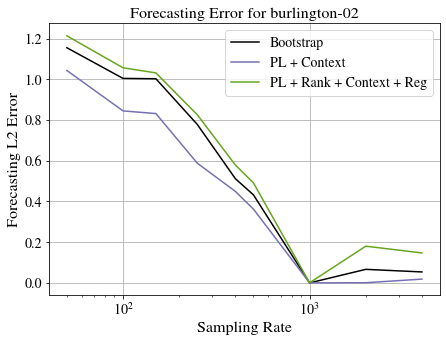

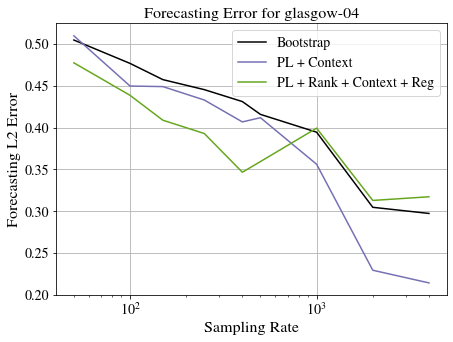

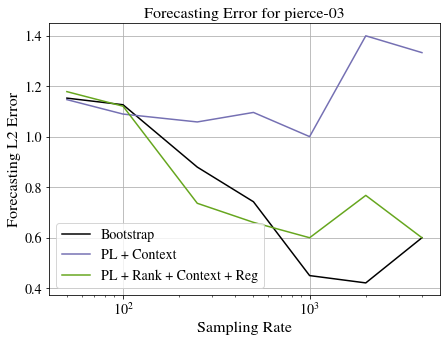

In [14]:
num_simulations = 250
for election_name in win_shares_results:        
 
    correct_winner = election_winners[election_name]
    cands = election_candidates[election_name]
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_title(f"Forecasting Error for {election_name}")
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("Forecasting L2 Error")
    
    for model_name in win_shares_results[election_name]:

        sample_sizes = [size for size in win_shares_results[election_name][model_name]]
        errors_by_size = []
        for size in sample_sizes:
            if size >= 1000:
                num_trials = 10
            elif election_name in ["pierce-03", "sf-11"]:
                num_trials = 75
            elif election_name in ["burlington-02", "glasgow-04"]:
                num_trials = 200
            
            errors = []
            for trial_idx in range(num_trials):
                # for num_simulations, sample n ballots to get a cand win shares vector
                cand_wins = {
                    cand: win_shares_results[election_name][model_name][size][cand][trial_idx]\
                    for cand in cands
                }
                
                # add error to errors
#                 error = cand_wins[correct_winner] / num_simulations
                error = 0
                for cand in cands:
                    p = cand_wins[cand] / num_simulations
                    error += (win_shares_oracle[election_name][1.0][cand] - p)**2
                errors.append(error)
#             if model_name == "PL + Context":
#                 print([f"{x:.1e}" for x in errors])
            errors_by_size.append(np.mean(errors))
            
        ax.plot(sample_sizes, errors_by_size, 
                label=model_name, 
                color=get_color_from_model_name(model_name))
    ax.legend()
    ax.grid()
    ax.set_xscale("log")

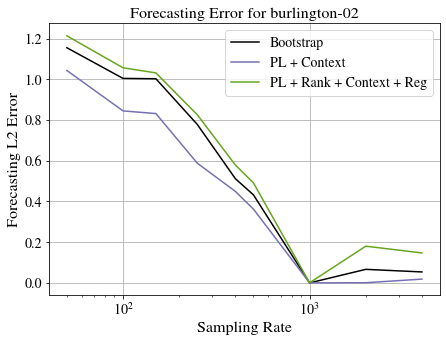

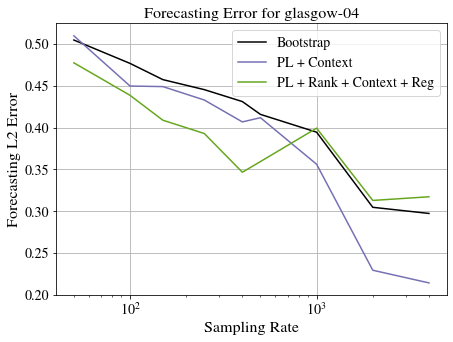

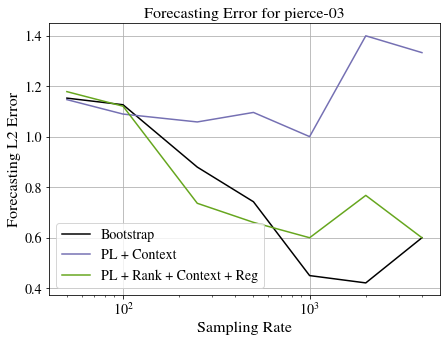

In [14]:
num_simulations = 250
for election_name in win_shares_results:        
 
    correct_winner = election_winners[election_name]
    cands = election_candidates[election_name]
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_title(f"Forecasting Error for {election_name}")
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("Forecasting L2 Error")
    
    for model_name in win_shares_results[election_name]:

        sample_sizes = [size for size in win_shares_results[election_name][model_name]]
        errors_by_size = []
        for size in sample_sizes:
            if size >= 1000:
                num_trials = 10
            elif election_name in ["pierce-03", "sf-11"]:
                num_trials = 75
            elif election_name in ["burlington-02", "glasgow-04"]:
                num_trials = 200
            
            errors = []
            for trial_idx in range(num_trials):
                # for num_simulations, sample n ballots to get a cand win shares vector
                cand_wins = {
                    cand: win_shares_results[election_name][model_name][size][cand][trial_idx]\
                    for cand in cands
                }
                
                # add error to errors
#                 error = cand_wins[correct_winner] / num_simulations
                error = 0
                for cand in cands:
                    p = cand_wins[cand] / num_simulations
                    error += (win_shares_oracle[election_name][1.0][cand] - p)**2
                errors.append(error)
#             if model_name == "PL + Context":
#                 print([f"{x:.1e}" for x in errors])
            errors_by_size.append(np.mean(errors))
            
        ax.plot(sample_sizes, errors_by_size, 
                label=model_name, 
                color=get_color_from_model_name(model_name))
    ax.legend()
    ax.grid()
    ax.set_xscale("log")

In [27]:
rate = 0.32 
for cand in election_candidates["sf-07"]:
    p = np.mean(win_shares_results['sf-07']['PL + Rank + Context'][rate][cand]) / 100
    print(f"{cand}: {p}")

1: 0.2636
2: 0.0
3: 0.0
4: 0.7364
5: 0.0
6: 0.0
7: 0.0
